[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework3.ipynb)


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

In [40]:
# We load data which contain different medical parameters and classifies if breast cancer is benign or malignant
cancer_data = load_breast_cancer()

# We split data into three sets: training, validation and test in proportion 0.7 : 0.2 : 0.1
X_train, X_test, Y_train, Y_test = train_test_split(cancer_data.data, cancer_data.target, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.22, random_state=42, shuffle=True)

# We perform logistic regression
logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(X_train, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**ROC Curve** is a curve that gives us information about performance of a classifier. It plots TPR (True Positive Rate) which is often called sensitivity against FPR (False Positive Rate), which is often called specificity. Then we calculate **AUC** which stands for "Area Under Curve" -- the larger area, the larger is probability that our model will give a higher value to positive observation that to negative one.

AUC score = 0.9873754152823919
TPR for threshold = 0.5 is equal to 0.6142857142857143


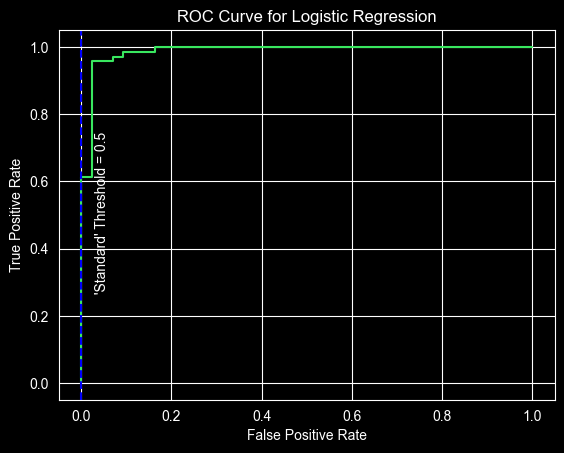

In [62]:
val_predictions = logistic_model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_val, val_predictions)
plt.plot(fpr, tpr, color = "#39e75f")

plt.axvline(x = fpr[np.argmax(tpr > 0.5)], linestyle='--', color = "blue")
plt.text(fpr[np.argmax(tpr > 0.5)] + 0.03, 0.5, f" 'Standard' Threshold = 0.5", rotation=90, va='center')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
print("AUC score = " + str(auc(fpr, tpr)))
print(f"TPR for threshold = 0.5 is equal to {tpr[np.argmax(tpr > 0.5)]}")

To choose optimal threshold we have to take into account that we are analysing medical data, which recognises type of cancer. This means that we want to be 100% sure that we catch all malignant cases, even for price of confusing some benign cases. Because of that we decide to optimize TPR over FPR and choose the first threshold for which $TPR > 0.99$.

Best threshold for our data is 0.020535422536857226
AUC score = 0.9873754152823919


Text(0.5, 1.0, 'ROC Curve for Logistic Regression')

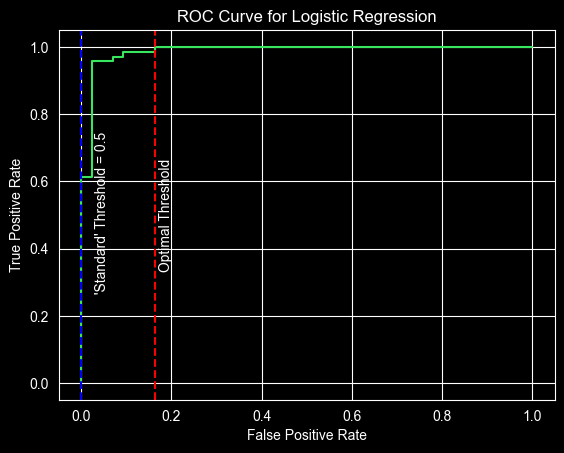

In [60]:
index = np.argmax(tpr > 0.99)
best_threshold = thresholds[index]
print(f"Best threshold for our data is {best_threshold}")
print("AUC score = " + str(auc(fpr, tpr)))
plt.plot(fpr, tpr, color = "#39e75f")

plt.axvline(x=fpr[index], linestyle='--', color = "red")
plt.text(fpr[index] + 0.01, 0.5, f"Optimal Threshold", rotation=90, va='center')

plt.axvline(x = fpr[np.argmax(tpr > 0.5)], linestyle='--', color = "blue")
plt.text(fpr[np.argmax(tpr > 0.5)] + 0.03, 0.5, f" 'Standard' Threshold = 0.5", rotation=90, va='center')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')


Now we apply our chosen threshold, to see the results on test set.

In [51]:
prob_test = logistic_model.predict_proba(X_test)[:, 1]
y_pred = (prob_test > best_threshold)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       0.95      1.00      0.98        40

    accuracy                           0.96        57
   macro avg       0.98      0.94      0.96        57
weighted avg       0.97      0.96      0.96        57



# Results
 - If we set threshold to 'standard' 0.5, would get only 0.61 TPR, which is unacceptable in case of our data.
 - Firstly, our model has 1.0 precision of catching 0 class and 0.95 with catching 1 class. It also has 1.0 recall in 1 class It is essential, beacuse as we have mentioned earlier in this case we want to be 100% that we catch all malignant cases, so it is important, that if our model says that the cancer is benign, it actually is benign and we don't miss anything.
  - Secondly, f1-score and accuracy are also on a very good level, which generally says, that or model predicts almost every case correctly.

# Conclusions from reading and plotting:
- Shifting the threshold changes the relation between specificity and sensitivity. The higher is the threshold, the harder is for an observation to be marked as good, so we minimize probablility that we classify something as 'good', which should be classified as 'bad'. On the other hand, if we lower the threshold, then we minimize probability that we reject something, which should be marked as positive.
- Choosing the best threshold depends on data we are working with and the context of this data. If we work on medical data, like in an example before, we would focus on maximing TPR, because we don't want to miss any positive case. Otherwise, in case of spam filters, it is more crucial to not label legit e-mail as spam, i.e. we want to minimize FPR.
- ROC curve helps us see the relation between FPR and TPR and decide which point will satify our condition. In our example, if the sama data was given but in the context of spam filtering, we would choose the threshold, which corresponds to the first jump, around y = 0.6, because it has specificity equals approximately zero, meanwhile sensitivity score is satisfactory.
- AUC measures area under ROC curve, so it takes value from 0 to 1. It represents probablility that our model will give higher value to a positive example, then to negative one.